
# unemployment in India during covid-19

### objective of analysis is -

* To know the covid-19 impact on job market

* which state survive and which state has more impact on


## This dataset contains the unemployment rate of all the states in India

* States = states in India
* Date = date which the unemployment rate observed
* Frequency = measuring frequency (Monthly)
* Estimated Unemployment Rate (%) = percentage of people unemployed in each States of India
* Estimated Employed = Number of people employed
* Estimated Labour Participation Rate (%) = The labour force participation rate is the portion of the working population in the 16-64 years' age group in the economy currently in employment or seeking employment.





# Index

* <a href="#Data-Import">Data Import</a>
* <a href="#Stats">Stats</a>
* <a href="#Data-exploratory-Analysis">Data exploratory Analysis</a>
* <a href="#Impact-of-Lockdown-on-States-Estimated-Employed">Impact-of-Lockdown-on-States-Estimated-Employed</a>


In [5]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import calendar

In [6]:
import datetime as dt

import plotly.io as pio
pio.templates

Templates configuration
-----------------------
    Default template: 'plotly'
    Available templates:
        ['ggplot2', 'seaborn', 'simple_white', 'plotly',
         'plotly_white', 'plotly_dark', 'presentation', 'xgridoff',
         'ygridoff', 'gridon', 'none']

In [10]:
import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff
from IPython.display import HTML

# Data Import

In [11]:
# Load the Unemployment in India dataset
df = pd.read_csv(
    r"C:\Users\rrama_t5uaug6\Downloads\Unemployment_Rate_upto_11_2020.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [12]:
df.head()

,Region,Date,Frequency,Estimated_Unemployment_Rate,Estimated_Employed,Estimated_Labour_Participation_Rate,Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Region                                267 non-null    object 
 1    Date                                 267 non-null    object 
 2    Frequency                            267 non-null    object 
 3    Estimated_Unemployment_Rate          267 non-null    float64
 4    Estimated_Employed                   267 non-null    int64  
 5    Estimated_Labour_Participation_Rate  267 non-null    float64
 6   Region.1                              267 non-null    object 
 7   longitude                             267 non-null    float64
 8   latitude                              267 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.9+ KB


In [16]:
df.isnull().sum()

States                                 0
Date                                   0
Frequency                              0
Estimated Unemployment Rate            0
Estimated Employed                     0
Estimated Labour Participation Rate    0
Region                                 0
longitude                              0
latitude                               0
dtype: int64

In [17]:
df.columns =['States','Date','Frequency','Estimated Unemployment Rate','Estimated Employed','Estimated Labour Participation Rate','Region','longitude','latitude']

In [19]:
df['Date'] = pd.to_datetime(df['Date'],dayfirst=True)

In [20]:
df['Frequency']= df['Frequency'].astype('category')

In [21]:
df['Month'] =  df['Date'].dt.month



In [22]:
df['Month_int'] = df['Month'].apply(lambda x : int(x))

In [23]:

df['Month_name'] =  df['Month_int'].apply(lambda x: calendar.month_abbr[x])

In [24]:
df['Region'] = df['Region'].astype('category')

In [25]:
df.drop(columns='Month',inplace=True)
df.head(3)

,States,Date,Frequency,Estimated Unemployment Rate,Estimated Employed,Estimated Labour Participation Rate,Region,longitude,latitude,Month_int,Month_name
0,Andhra Pradesh,2020-01-31,M,5.48,16635535,41.02,South,15.9129,79.74,1,Jan
1,Andhra Pradesh,2020-02-29,M,5.83,16545652,40.90,South,15.9129,79.74,2,Feb
2,Andhra Pradesh,2020-03-31,M,5.79,15881197,39.18,South,15.9129,79.74,3,Mar


# Stats

In [28]:
print(df.columns.tolist())

['States', 'Date', 'Frequency', 'Estimated Unemployment Rate', 'Estimated Employed', 'Estimated Labour Participation Rate', 'Region', 'longitude', 'latitude', 'Month_int', 'Month_name']


In [30]:
for column in df.columns:
    print(repr(column))

'States'
'Date'
'Frequency'
'Estimated Unemployment Rate'
'Estimated Employed'
'Estimated Labour Participation Rate'
'Region'
'longitude'
'latitude'
'Month_int'
'Month_name'


In [33]:
# Select the main columns for statistical analysis
df_stats = df[['Estimated Unemployment Rate',
               'Estimated Employed',
               'Estimated Labour Participation Rate']]

# Display summary statistics
df_stats.describe()

,Estimated Unemployment Rate,Estimated Employed,Estimated Labour Participation Rate
count,267.000000,2.670000e+02,267.000000
mean,12.236929,1.396211e+07,41.681573
std,10.803283,1.336632e+07,7.845419
min,0.500000,1.175420e+05,16.770000
25%,4.845000,2.838930e+06,37.265000
50%,9.650000,9.732417e+06,40.390000
75%,16.755000,2.187869e+07,44.055000
max,75.850000,5.943376e+07,69.690000


In [35]:
region_stats = df.groupby(['Region'])[['Estimated Unemployment Rate','Estimated Employed','Estimated Labour Participation Rate']].mean().reset_index()

region_stats = round(region_stats,2)


region_stats

C:\Users\rrama_t5uaug6\AppData\Local\Temp\ipykernel_568\2789248630.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,Region,Estimated Unemployment Rate,Estimated Employed,Estimated Labour Participation Rate
0,East,13.92,19602366.90,40.11
1,North,15.89,13072487.92,38.70
2,Northeast,10.95,3617105.53,52.06
3,South,10.45,14040589.33,40.44
4,West,8.24,18623512.72,41.26


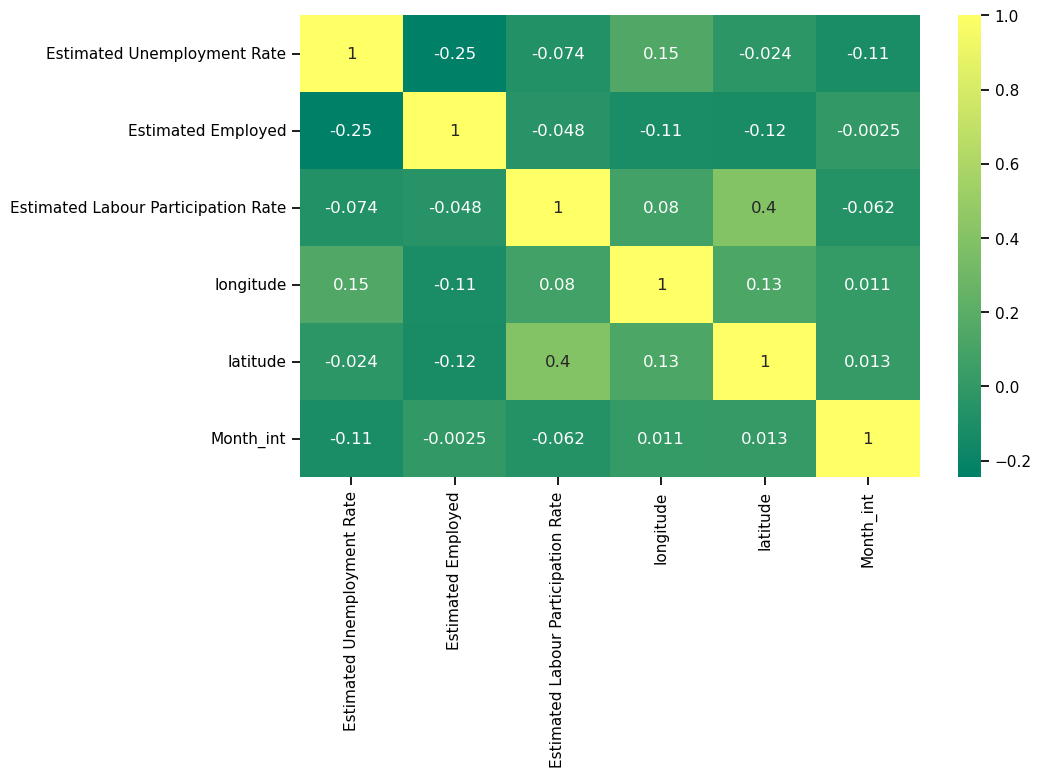

In [36]:
heat_maps = df[['Estimated Unemployment Rate',
       'Estimated Employed', 'Estimated Labour Participation Rate',
       'longitude', 'latitude', 'Month_int']]

heat_maps = heat_maps.corr()

plt.figure(figsize=(10,6))
sns.set_context('notebook',font_scale=1)
sns.heatmap(heat_maps, annot=True,cmap='summer');

# Data exploratory Analysis

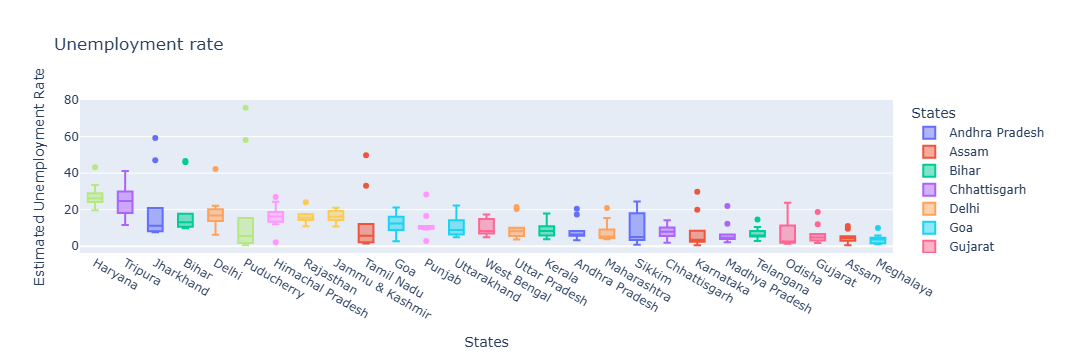

In [37]:
fig = px.box(df,x='States',y='Estimated Unemployment Rate',color='States',title='Unemployment rate',template='plotly')
fig.update_layout(xaxis={'categoryorder':'total descending'})
fig.show()

# The below box shows unemployement rate in each state in India

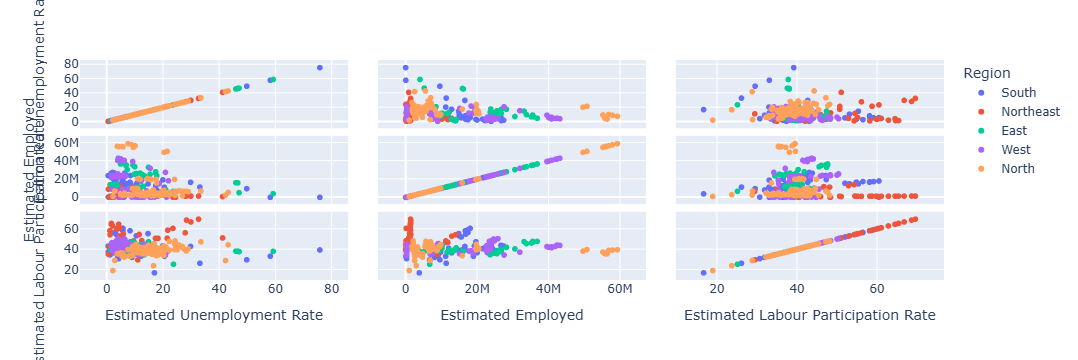

In [38]:
fig = px.scatter_matrix(df,template='plotly',
    dimensions=['Estimated Unemployment Rate','Estimated Employed',
                'Estimated Labour Participation Rate'],
    color='Region')
fig.show()

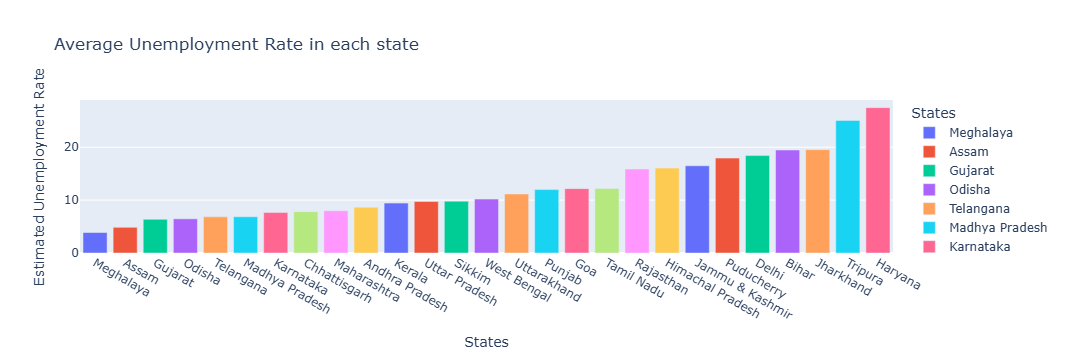

In [39]:
plot_ump = df[['Estimated Unemployment Rate','States']]

df_unemp = plot_ump.groupby('States').mean().reset_index()

df_unemp = df_unemp.sort_values('Estimated Unemployment Rate')

fig = px.bar(df_unemp, x='States',y='Estimated Unemployment Rate',color='States',
            title='Average Unemployment Rate in each state',template='plotly')

fig.show()

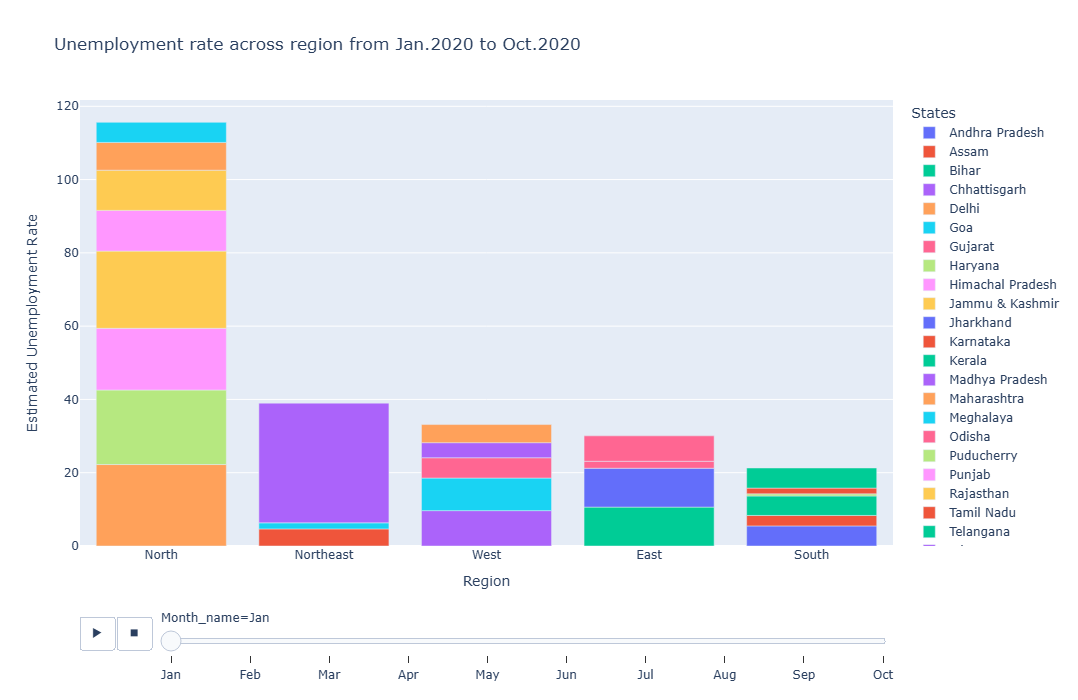

In [40]:
fig = px.bar(df, x='Region',y='Estimated Unemployment Rate',animation_frame = 'Month_name',color='States',
            title='Unemployment rate across region from Jan.2020 to Oct.2020', height=700,template='plotly')

fig.update_layout(xaxis={'categoryorder':'total descending'})

fig.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = 2000

fig.show()

In [41]:
unemplo_df = df[['States','Region','Estimated Unemployment Rate','Estimated Employed','Estimated Labour Participation Rate']]

unemplo = unemplo_df.groupby(['Region','States'])['Estimated Unemployment Rate'].mean().reset_index()


C:\Users\rrama_t5uaug6\AppData\Local\Temp\ipykernel_568\3906838429.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



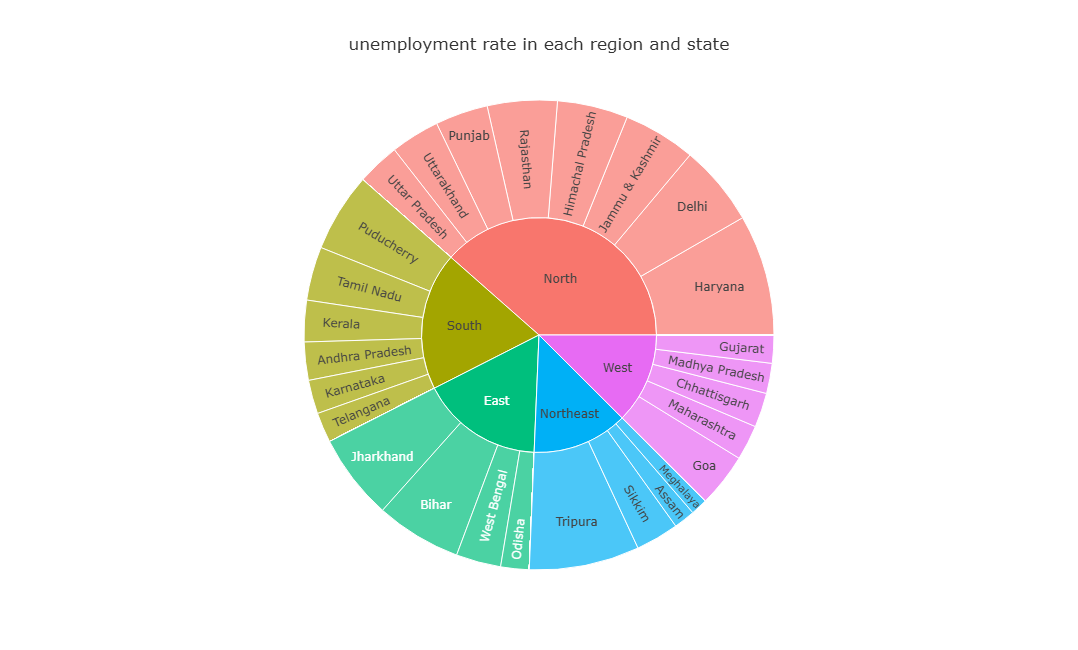

In [42]:
fig = px.sunburst(unemplo, path=['Region','States'], values='Estimated Unemployment Rate',
                  color_continuous_scale='Plasma',title= 'unemployment rate in each region and state',
                  height=650,template='ggplot2')


fig.show()


# Impact of Lockdown on States Estimated Employed


* On 24 March 2020, the Government of India under Prime Minister Narendra Modi ordered a nationwide lockdown for 21 days



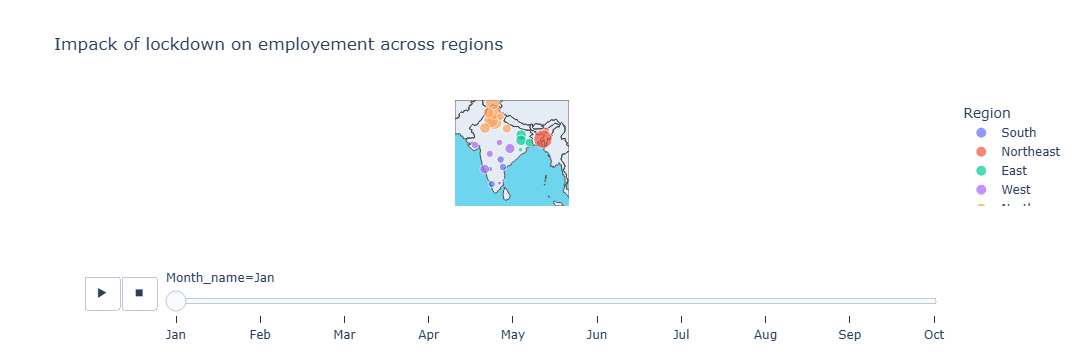

In [43]:
fig = px.scatter_geo(df,'longitude', 'latitude', color="Region",
                     hover_name="States", size="Estimated Unemployment Rate",
                     animation_frame="Month_name",scope='asia',template='plotly',title='Impack of lockdown on employement across regions')

fig.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = 2000

fig.update_geos(lataxis_range=[5,35], lonaxis_range=[65, 100],oceancolor="#6dd5ed",
    showocean=True)

fig.show()

In [44]:
lock = df[(df['Month_int'] >= 4) & (df['Month_int'] <=7)]

bf_lock = df[(df['Month_int'] >= 1) & (df['Month_int'] <=4)]


In [45]:
g_lock = lock.groupby('States')['Estimated Unemployment Rate'].mean().reset_index()

g_bf_lock = bf_lock.groupby('States')['Estimated Unemployment Rate'].mean().reset_index()


g_lock['Unemployment Rate before lockdown'] = g_bf_lock['Estimated Unemployment Rate']

g_lock.columns = ['States','Unemployment Rate after lockdown','Unemployment Rate before lockdown']

g_lock.head(2)

,States,Unemployment Rate after lockdown,Unemployment Rate before lockdown
0,Andhra Pradesh,12.3975,9.4025
1,Assam,6.2450,6.2250


In [46]:
# percentage change in unemployment rate
g_lock['percentage change in unemployment'] = round(g_lock['Unemployment Rate after lockdown'] - g_lock['Unemployment Rate before lockdown']/g_lock['Unemployment Rate before lockdown'],2)

In [47]:
plot_per = g_lock.sort_values('percentage change in unemployment')

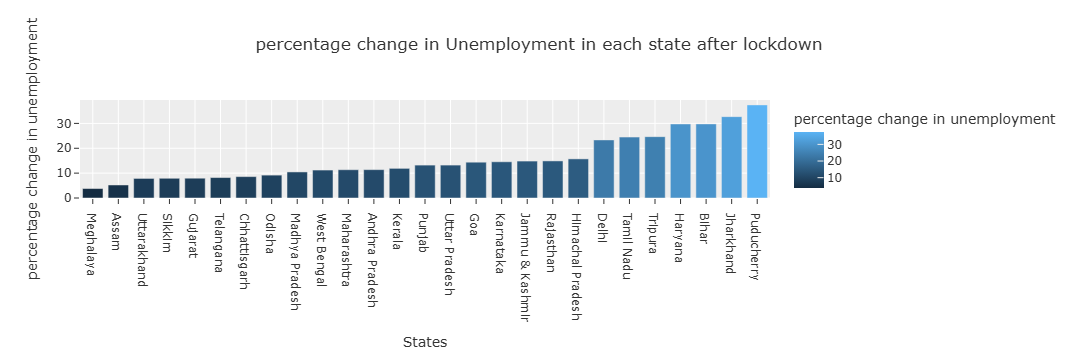

In [48]:
# percentage change in unemployment after lockdown

fig = px.bar(plot_per, x='States',y='percentage change in unemployment',color='percentage change in unemployment',
            title='percentage change in Unemployment in each state after lockdown',template='ggplot2')

fig.show()


# most impacted states/UT

* Puducherry
* Jharkhand
* Bihar
* Haryana
* Tripura


In [50]:
# function to sort value based on impact

def sort_impact(x):
    if x <= 10:
        return 'impacted States'
    elif x <= 20:
        return 'hard impacted States'
    elif x <= 30:
        return 'harder impacted States'
    elif x <= 40:
        return 'hardest impacted States'
    return x    


In [51]:
plot_per['impact status'] = plot_per['percentage change in unemployment'].apply(lambda x:sort_impact(x))



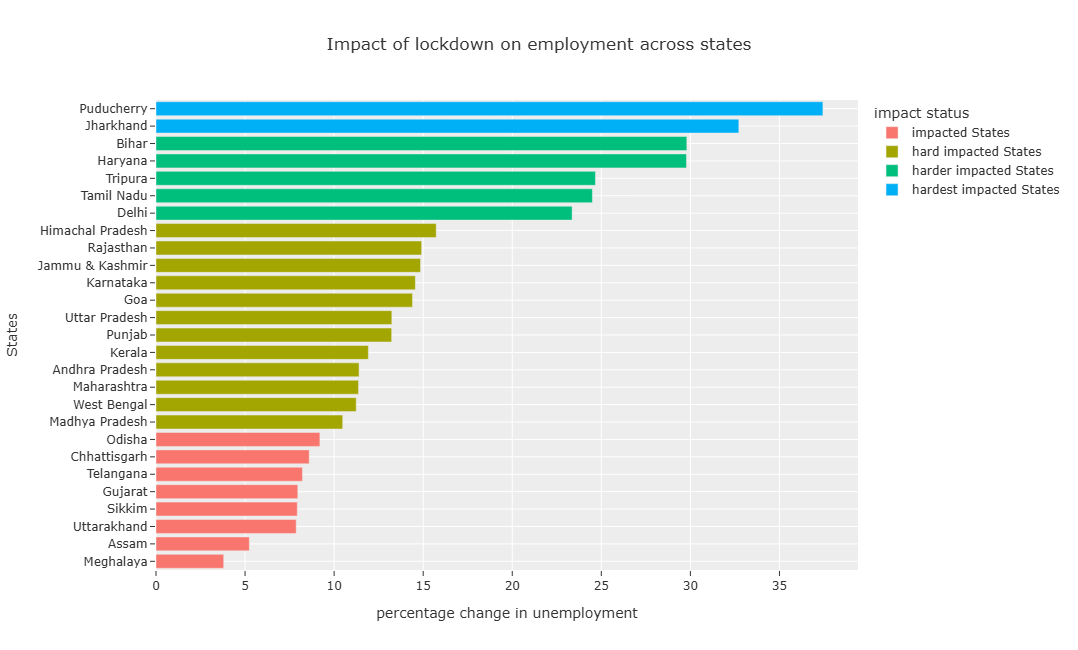

In [52]:
fig = px.bar(plot_per, y='States',x='percentage change in unemployment',color='impact status',
            title='Impact of lockdown on employment across states',template='ggplot2',height=650)


fig.show()

## Correlation Analysis

Correlation analysis is used to examine the relationships between unemployment rate, employment, and labour participation. The correlation matrix helps identify the strength and direction of relationships between the numerical variables.

In [53]:
# Select numerical columns for correlation analysis
correlation_data = df[
    [
        'Estimated Unemployment Rate',
        'Estimated Employed',
        'Estimated Labour Participation Rate'
    ]
]

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

# Display the correlation matrix
print(correlation_matrix)

                                     Estimated Unemployment Rate  \
Estimated Unemployment Rate                             1.000000   
Estimated Employed                                     -0.245176   
Estimated Labour Participation Rate                    -0.073540   

                                     Estimated Employed  \
Estimated Unemployment Rate                   -0.245176   
Estimated Employed                             1.000000   
Estimated Labour Participation Rate           -0.047948   

                                     Estimated Labour Participation Rate  
Estimated Unemployment Rate                                    -0.073540  
Estimated Employed                                             -0.047948  
Estimated Labour Participation Rate                             1.000000  


### Observation

The correlation analysis shows a weak negative relationship between the unemployment rate and estimated employment, with a correlation of approximately -0.25. The relationship between unemployment and labour participation is also weak and negative at approximately -0.07. The correlation between estimated employment and labour participation is approximately -0.05, indicating a very weak relationship in this dataset. These results represent statistical associations and should not be interpreted as evidence of causation.

<Axes: xlabel='Region'>

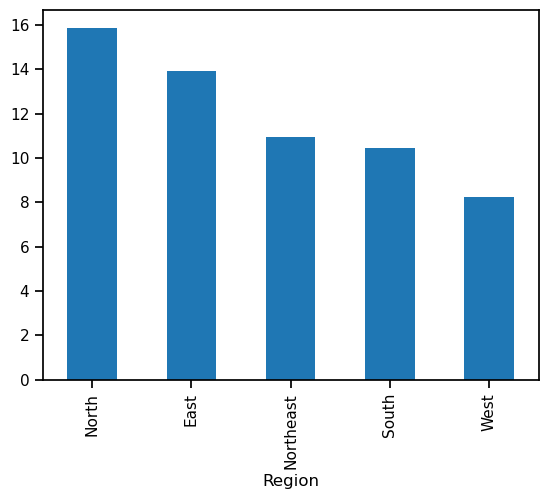

In [59]:
area_unemployment.plot(kind='bar')

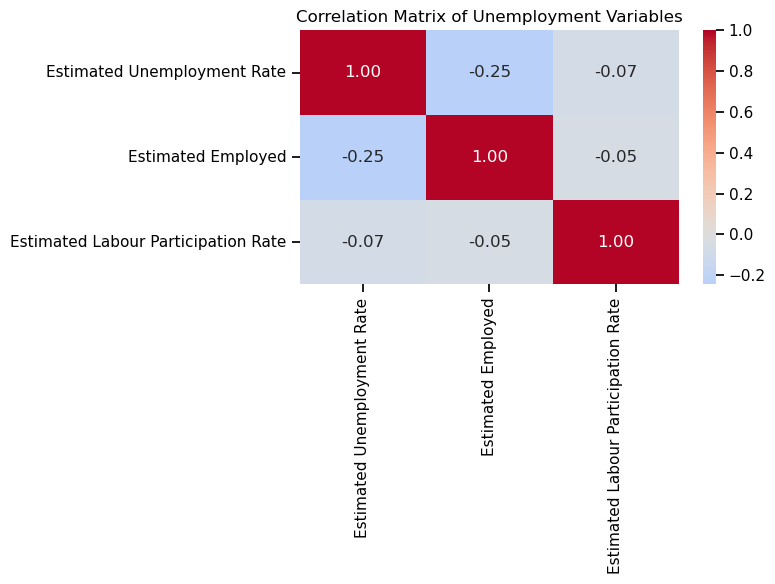

In [54]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of Unemployment Variables')
plt.tight_layout()
plt.show()

## Area Analysis

The unemployment rate is compared across different geographical areas to identify regional differences in unemployment during the period covered by the dataset.

In [56]:
# Calculate average unemployment rate by region
area_unemployment = (
    df.groupby('Region', observed=False)['Estimated Unemployment Rate']
      .mean()
      .sort_values(ascending=False)
)

print("Average Unemployment Rate by Region:")
print(area_unemployment)

Average Unemployment Rate by Region:
Region
North        15.889620
East         13.916000
Northeast    10.950263
South        10.454667
West          8.239000
Name: Estimated Unemployment Rate, dtype: float64


plt.figure(figsize=(10, 6))

area_unemployment.plot(kind='bar')

plt.title('Average Unemployment Rate by Region')
plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Key Findings

The unemployment analysis produced several important findings:

- The dataset contains unemployment observations for multiple Indian states during 2020.
- The unemployment rate varies considerably across states and over time.
- Most observations are concentrated at relatively lower unemployment rates, while some observations show substantially higher unemployment.
- The state-wise analysis shows noticeable differences in average unemployment rates between states.
- The time-series analysis shows that unemployment levels changed during 2020.
- The lockdown analysis shows that the percentage change in unemployment was different across states.
- Some states experienced substantially larger increases in unemployment after the lockdown period than others.
- The correlation analysis provides insight into the relationships between unemployment, employment, and labour-force participation.
- The dataset was checked for missing values and duplicate records during the cleaning process.

## Conclusion

This project analyzed unemployment patterns in India using Python. The analysis involved data cleaning, exploratory data analysis, statistical analysis, visualization, state-wise comparison, time-series analysis, and examination of the impact of the COVID-19 lockdown period.

The analysis shows that unemployment varied considerably across Indian states and over time. The state-wise analysis highlights geographical differences, while the time-series analysis demonstrates changes in unemployment throughout 2020.

The lockdown analysis provides an additional view of how unemployment changed across different states during the COVID-19 period. The results demonstrate how data analysis and visualization can be used to identify patterns and differences in labour-market conditions.

Overall, the project demonstrates the use of Python, Pandas, Matplotlib, Seaborn, and data visualization techniques to explore and interpret a real-world unemployment dataset.